# Graficos Resumen y Matriz de Competicion
Lee **solo los resultados de la Parte 1 (competicion)** de los 16 cuadernos.
Requiere que cada cuaderno haya sido ejecutado y haya generado su JSON en `../resultados/metricas/`.


In [8]:
import sys
sys.path.insert(0, '..')
import os
import pandas as pd
from utilidades.evaluacion import cargar_todos_resultados
from utilidades.graficos   import graficar_resumen, graficar_matriz_competicion


## Carga de resultados de competicion

In [9]:
# seccion='competicion' filtra solo los modelos de la Parte 1
df = cargar_todos_resultados('../resultados/metricas/', seccion='competicion')

combinaciones = df.groupby(['ventana_entrada','ventana_salida']).ngroups
print(f'Combinaciones cargadas: {combinaciones} / 16')
if combinaciones < 16:
    faltantes = [(e, s) for e in [5,10,30,90] for s in [1,5,30,90]
                 if df[(df.ventana_entrada==e)&(df.ventana_salida==s)].empty]
    print('Faltan:', faltantes)

display(df.pivot_table(index='ventana_salida', columns='ventana_entrada',
                        values='mae_test', aggfunc='min').round(5))


Combinaciones cargadas: 10 / 16
Faltan: [(5, 90), (10, 1), (10, 5), (30, 90), (90, 1), (90, 90)]


ventana_entrada,5,10,30,90
ventana_salida,,,,
1,0.01224,NaN,0.01225,NaN
5,0.00558,NaN,0.00558,0.00559
30,0.00232,0.00232,0.00232,0.00232
90,NaN,0.00126,NaN,NaN


## Graficos resumen por ventana de salida (Parte 1 — Competicion)

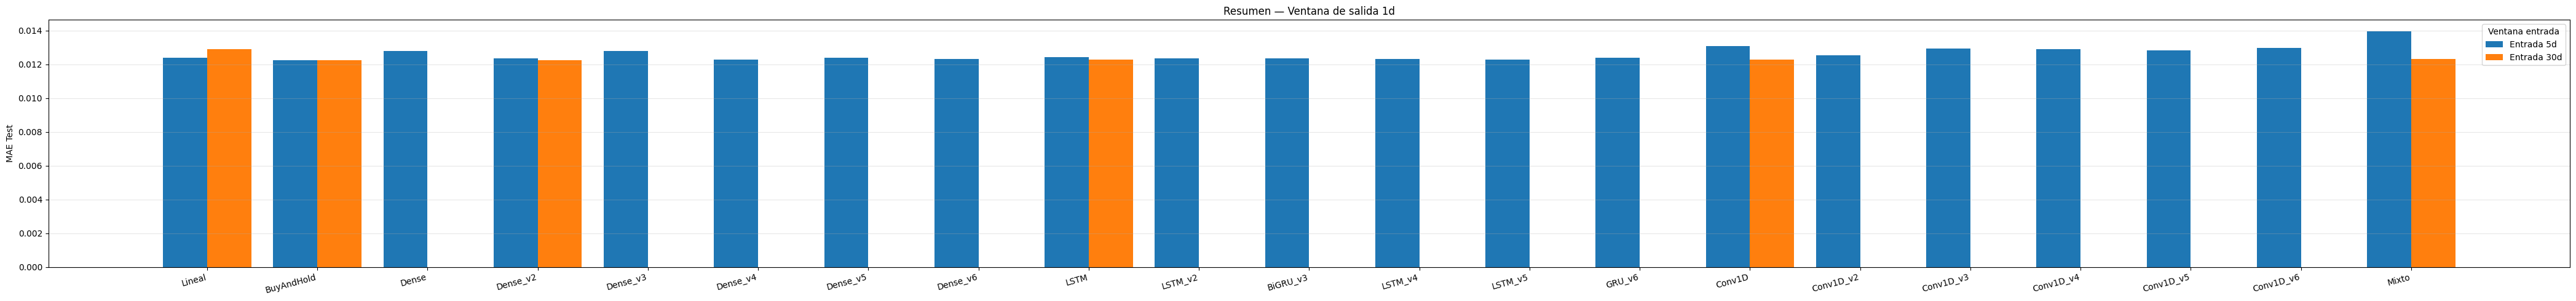

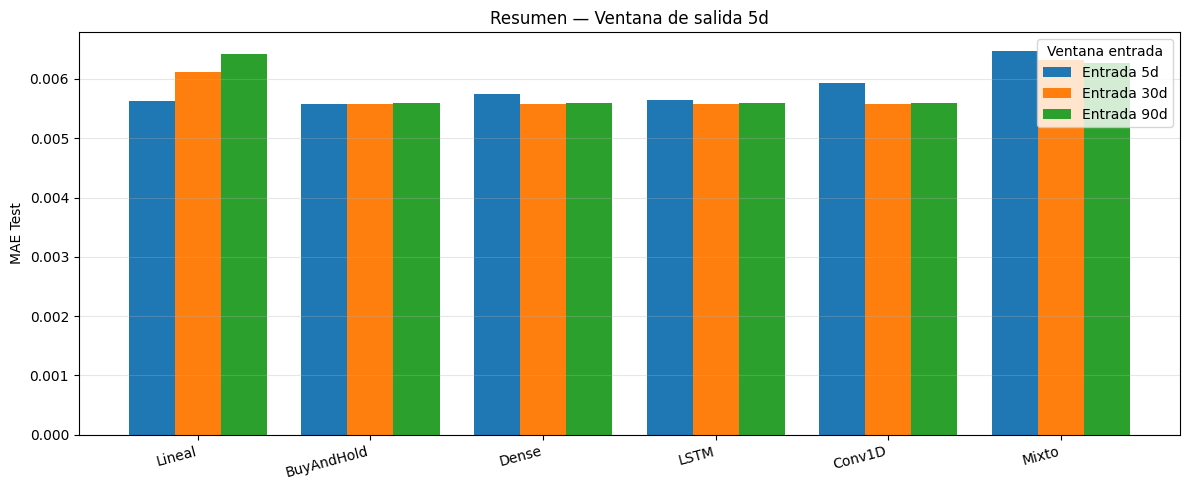

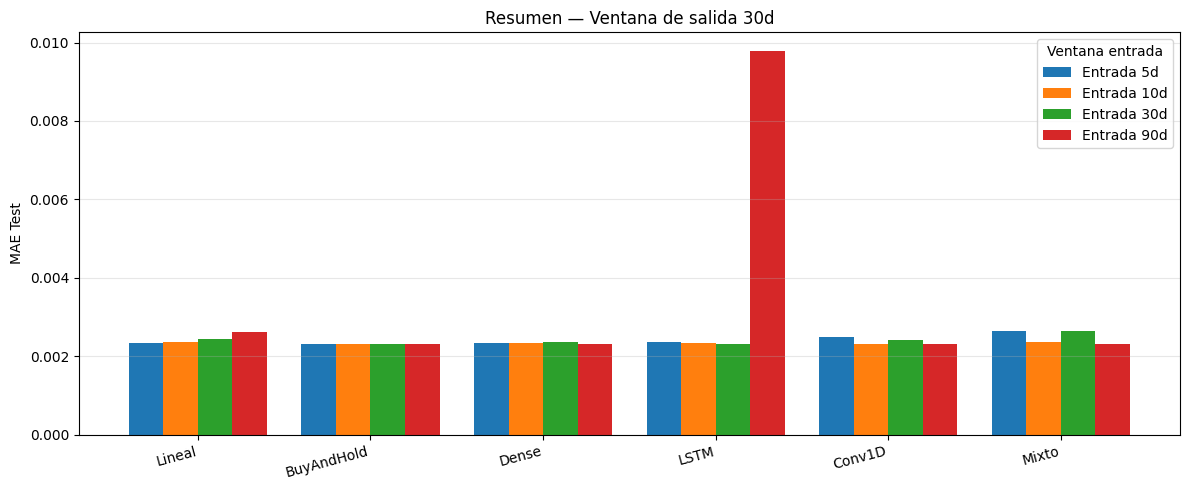

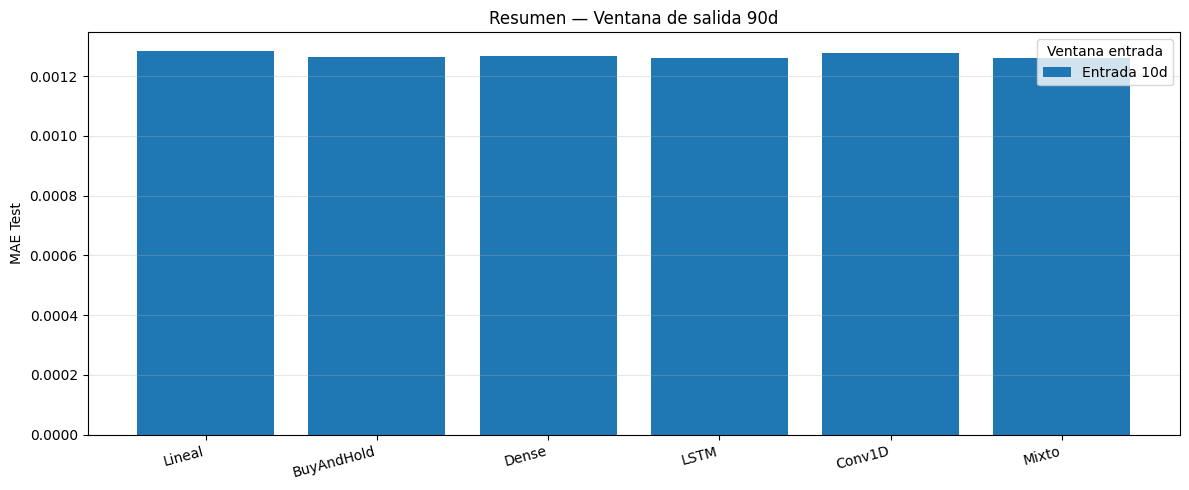

In [10]:
for ventana_sal in [1, 5, 30, 90]:
    graficar_resumen(df, ventana_sal)


## Matriz de competicion — mejor MAE test por combinacion

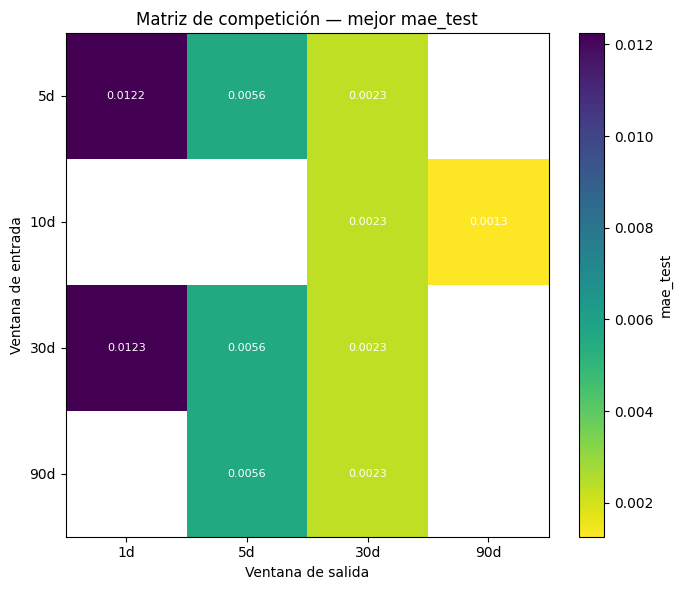

In [11]:
graficar_matriz_competicion(df)


## Efecto del preprocesado (Parte 2 — Investigacion)

In [12]:
# Comparativa entre el mejor modelo sin y con preprocesado, por combinacion
df_inv = cargar_todos_resultados('../resultados/metricas/', seccion='investigacion')

if df_inv.empty:
    print('Sin datos de investigacion todavia. Ejecuta la Parte 2 de los cuadernos.')
else:
    # Para cada combinacion: mejor MAE test de competicion vs investigacion
    mejor_comp = df.groupby(['ventana_entrada','ventana_salida'])['mae_test'].min().rename('mae_competicion')
    mejor_inv  = df_inv.groupby(['ventana_entrada','ventana_salida'])['mae_test'].min().rename('mae_investigacion')
    comparativa = pd.concat([mejor_comp, mejor_inv], axis=1).round(6)
    comparativa['mejora_%'] = ((comparativa['mae_competicion'] - comparativa['mae_investigacion'])
                                / comparativa['mae_competicion'] * 100).round(1)
    display(comparativa)


mae_competicion  mae_investigacion  mejora_%
ventana_entrada ventana_salida                                              
5               1                      0.012243           0.742293   -5963.0
                5                      0.005581           0.313762   -5522.0
                30                     0.002319           0.105664   -4456.4
10              30                     0.002319           0.105601   -4453.7
                90                     0.001262           0.052185   -4035.1
30              1                      0.012251           0.715676   -5741.8
                5                      0.005578           0.292693   -5147.3
                30                     0.002319           0.107512   -4536.1
90              5                      0.005589           0.291364   -5113.2
                30                     0.002317           0.105331   -4446.0